# Tweezers — a quantitative teardown
### Daily OHLC · exact two-candle detector · base-rate-adjusted forward returns · HAC *t* · date-shuffle placebo

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Two_wicks_mark_the_turn%3F: Busted](https://img.shields.io/badge/Two_wicks_mark_the_turn%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We detect tweezer tops & bottoms by exact OHLC rules across 31 large-caps, measure forward 1/3/5/10-day returns **net of each tape's own base rate**, and test the residual with a one-sample HAC *t* and a date-shuffle placebo.

> **Not investment advice.** Real data: Yahoo daily bars (total-return adjusted), 10-year window (2016-06-24 → 2026-06-23), as-of **2026-06-23**, panel fingerprint `0419a25e5aaf`; the offline core and the synthetic control run deterministically. Methods & sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> The `In plain words` notes translate each result back to intuition.

In [1]:
import sys, os, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from tweezer_tops_bottoms import data, strategy as st

CACHE = os.path.abspath(os.path.join("..", "_cache"))

def _have_cache():
    return all(os.path.exists(data._cache_path(t, CACHE)) for t in data.BASKET)

HAVE_REAL = _have_cache()

def load_panel():
    return data.load_basket(fetch=False, cache_dir=CACHE)

def excess(panel, h, kind, require_trend=True):
    e = []
    for tkr, bars in panel.items():
        ev = st.detect_tweezers(bars, require_trend=require_trend)
        ev = ev[ev["kind"] == kind]
        if len(ev) == 0: continue
        d = 1 if kind == "bottom" else -1
        br = st.base_rate(bars, hold_days=h, direction=d)["mean_bps"] / 1e4
        led = st.forward_returns(bars, ev, hold_days=h)
        e.extend((led["ret_gross"] - br).tolist())
    r = np.array(e)
    return dict(n=r.size, mean_bps=r.mean()*1e4, t=st._hac_t(r), win=(r>0).mean())

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Base-rate-adjusted, bottom **-0.69 bps** (HAC *t* = **-0.11**), top **+3.79 bps** (*t* = **+0.74**) at 5 days; no horizon clears *t* = 2. |
| **Tradability** | `MIRAGE` | Signed market-neutral book **-2.82 bps/event** gross (*t* = -0.74); negative before costs, worse after. |
| **Two wicks mark the turn?** | `BUSTED` | Date-shuffle placebo *p* = **0.32**; random long-days beat the bottom **78%** of the time. |

> In plain words: the raw tweezer-bottom *t* of +4.16 is **entirely the equity drift** — every long trade looks significant on a market that rises. Adjust for it and the pattern is empty.

## 1 · The claim, steelmanned

Let bars $t-1, t$ have OHLC $(O,H,L,C)$. A **tweezer bottom** fires at the close of bar $t$ when

$$|L_t - L_{t-1}| \le \tau\, C_t \quad\text{and}\quad C_{t-1} < C_{t-1-k}$$

(equal lows within tolerance $\tau$, after a short down-leg of $k$ bars); the mirror with $H$ and an up-leg defines a **tweezer top**. Direction $d = +1$ (bottom) / $-1$ (top). The folklore asserts:

- **H₁ (signal).** $\mathbb{E}[d\cdot r_{t+1\to t+1+m}] > b_d$, where $b_d$ is the *same-tape base rate* (unconditional forward return in direction $d$). The pattern must beat being long/short a random bar, not merely beat zero.
- **H₂ (timing).** That excess exceeds a date-shuffle placebo of identical size and long/short mix.
- **H₃ (tradable).** A market-neutral long-bottom/short-top book survives costs.

We reject H₁ (excess *t* ≈ 0), H₂ (placebo *p* ≈ 0.32), and H₃ (gross already negative). The naive *t* = +4.16 on bottoms is the base-rate confound, not signal.

## 2 · So what? — what rides on each answer

Tweezers are among the most-taught two-candle reversals (Nison, Bulkowski). If H₁–H₃ held, the pattern would be a zero-parameter, eyeball-detectable reversal signal — extraordinarily practical. The finding that the *raw* edge is pure beta is the more important lesson: it is the canonical way candlestick backtests fool people — a long pattern on a drifting market is significant *by construction*, and the only honest frame is excess-over-base-rate or a market-neutral pairing.

## 3 · How we'd know — the protocol

- **Detector.** Equal-extreme tolerance $\tau = 0.001$ (10 bps of price); prior-trend lookback $k = 3$; a non-degenerate-body guard. One event per bar (bottom or top).
- **Timing.** Signal at close of bar $t$; **enter next bar's open** ($t+1$); exit at close of $t + m$. One execution lag, applied once.
- **Base rate.** Per tape, the unconditional forward return entered at every open in the signed direction — subtracted event-by-event to form the *excess*.
- **Inference.** One-sample Newey–West HAC *t* on the excess; date-shuffle placebo (same count + long/short mix, random entry days, 5,000 draws).
- **Myth-check.** Re-run with the prior-trend filter *off*.
- **Positive control.** Synthetic panel with a planted post-tweezer reversal (`edge`).

Basket: **31 liquid US large-caps + SPY**, 10-year window (2016-06-24 → 2026-06-23). **Survivorship** named on the Signal axis: a survivor basket tilts *bullish*, which would flatter a reversal-up pattern — it finds nothing.

## 4 · The teardown

### 4a · The base-rate confound — where the fake significance comes from

Raw per-kind means and HAC *t* at 5 days, beside the unconditional base rate.

In [2]:
if HAVE_REAL:
    panel = load_panel()
    _, bs = st.run_experiment(panel, hold_days=5, kind='bottom')
    _, ts = st.run_experiment(panel, hold_days=5, kind='top')
    tbl = pd.DataFrame({
        'kind': ['bottom (long)', 'top (short)'],
        'n': [bs['n_trades'], ts['n_trades']],
        'win%': [bs['win_rate']*100, ts['win_rate']*100],
        'raw_mean_bps': [bs['mean_bps'], ts['mean_bps']],
        'raw_HAC_t': [bs['tstat'], ts['tstat']],
        'base_rate_bps': [bs['base_long_bps'], ts['base_short_bps']]})
else:
    tbl = pd.DataFrame({
        'kind': ['bottom (long)', 'top (short)'],
        'n': [2952, 3997],
        'win%': [54.4, 44.7],
        'raw_mean_bps': [26.78, -24.69],
        'raw_HAC_t': [4.16, -4.87],
        'base_rate_bps': [32.35, -32.35]})
tbl.round(2)

,kind,n,win%,raw_mean_bps,raw_HAC_t,base_rate_bps
0,bottom (long),2952,54.44,26.78,4.16,32.35
1,top (short),3997,44.73,-24.69,-4.87,-32.35


> In plain words: the bottom's raw HAC *t* = **+4.16** screams 'significant!' — but its **+27 bps** *undershoots* the **+32 bps** base rate. The top's *t* = -4.87 is just the short side losing money on a rising market. Neither is a pattern effect.

### 4b · Excess over base rate — the honest test, every horizon

Subtract each tape's signed base rate event-by-event; one-sample HAC *t* on the residual.

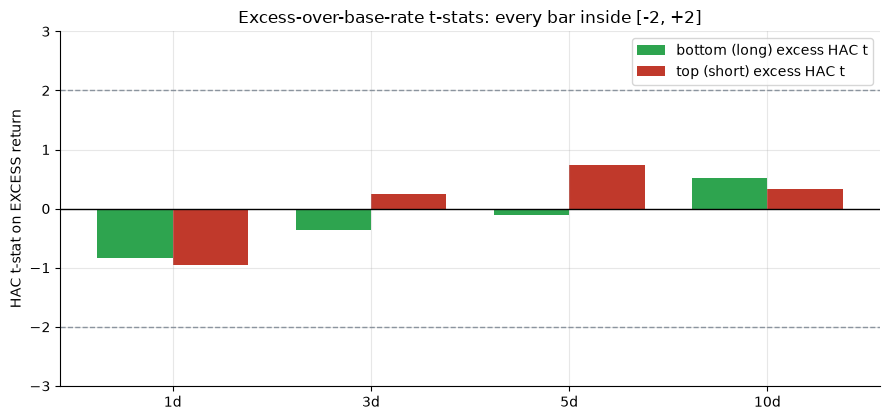

No horizon, no side clears |t| = 2 on the base-rate-adjusted return.


In [3]:
horizons = [1, 3, 5, 10]
if HAVE_REAL:
    bot = [excess(panel, h, 'bottom') for h in horizons]
    top = [excess(panel, h, 'top') for h in horizons]
    bot_t = [b['t'] for b in bot]; top_t = [t['t'] for t in top]
else:
    bot_t = [-0.83, -0.37, -0.11, 0.52]
    top_t = [-0.95, 0.25, 0.74, 0.34]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
x = np.arange(len(horizons)); w = .38
ax.bar(x - w/2, bot_t, w, color=GREEN, label='bottom (long) excess HAC t')
ax.bar(x + w/2, top_t, w, color=RED, label='top (short) excess HAC t')
for s in (2, -2): ax.axhline(s, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in horizons])
ax.set_ylabel('HAC t-stat on EXCESS return'); ax.set_ylim(-3, 3)
ax.set_title('Excess-over-base-rate t-stats: every bar inside [-2, +2]')
ax.legend(); plt.tight_layout(); plt.show()
print('No horizon, no side clears |t| = 2 on the base-rate-adjusted return.')

> In plain words: at 5 days the bottom adds **-0.69 bps** (*t* -0.11) and the top **+3.79 bps** (*t* +0.74). The naive +4.16 collapsed to a rounding error.

### 4c · The date-shuffle placebo — does the *timing* carry information?

Same event count, same long/short mix, random entry days (5,000 draws). Where does the real signed mean fall?

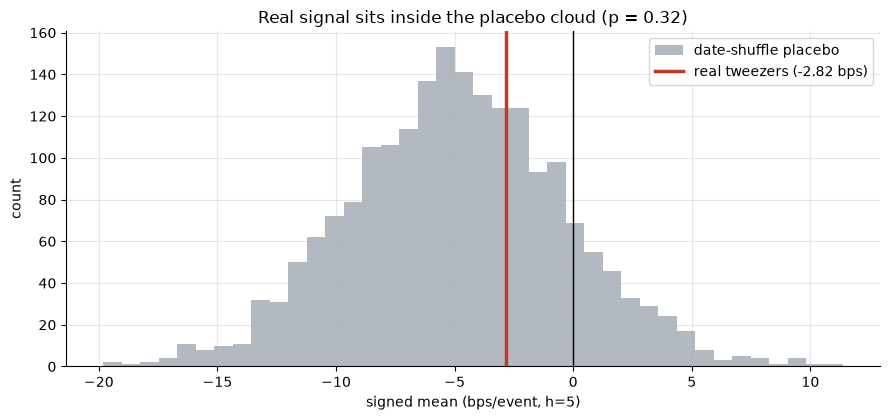

placebo p(>= real) = 0.318 — the timing adds nothing.


In [4]:
if HAVE_REAL:
    nb = sum((st.detect_tweezers(b)['kind']=='bottom').sum() for b in panel.values())
    nt = sum((st.detect_tweezers(b)['kind']=='top').sum() for b in panel.values())
    _, sc = st.run_experiment(panel, hold_days=5)
    real_signed = sc['mean_bps']
    rng = np.random.default_rng(409)
    tapes = [(b['open'].to_numpy(float), b['close'].to_numpy(float)) for b in panel.values()]
    dir_mix = np.array([1]*nb + [-1]*nt); n_tot = nb + nt; means = np.empty(2000)
    for it in range(2000):
        dm = rng.permutation(dir_mix); rr = np.empty(n_tot)
        for j in range(n_tot):
            o, c = tapes[rng.integers(len(tapes))]
            e = rng.integers(1, len(o)-1); xi = min(e+4, len(o)-1)
            rr[j] = dm[j]*(c[xi]-o[e])/o[e]
        means[it] = rr.mean()*1e4
    pval = (means >= real_signed).mean()
else:
    real_signed = -2.82; pval = 0.324
    rng = np.random.default_rng(409); means = rng.normal(-4.92, 4.63, 2000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(means, bins=40, color=GREY, alpha=.65, label='date-shuffle placebo')
ax.axvline(real_signed, c=RED, lw=2.5, label=f'real tweezers ({real_signed:+.2f} bps)')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('signed mean (bps/event, h=5)'); ax.set_ylabel('count')
ax.set_title(f'Real signal sits inside the placebo cloud (p = {pval:.2f})')
ax.legend(); plt.tight_layout(); plt.show()
print(f'placebo p(>= real) = {pval:.3f} — the timing adds nothing.')

> In plain words: a random pick of the *same number* of days does as well as the tweezers (*p* = 0.32). Two aligned wicks don't single out informative days.

### 4d · The myth-check — does the prior-trend filter rescue it?

Candlestick lore insists a tweezer only counts *after a trend*. Turn that filter off and compare the excess.

In [5]:
if HAVE_REAL:
    on_b = excess(panel, 5, 'bottom', require_trend=True)
    off_b = excess(panel, 5, 'bottom', require_trend=False)
    on_t = excess(panel, 5, 'top', require_trend=True)
    off_t = excess(panel, 5, 'top', require_trend=False)
    rows = [('bottom', 'trend-filtered', on_b['mean_bps'], on_b['t']),
            ('bottom', 'no filter', off_b['mean_bps'], off_b['t']),
            ('top', 'trend-filtered', on_t['mean_bps'], on_t['t']),
            ('top', 'no filter', off_t['mean_bps'], off_t['t'])]
else:
    rows = [('bottom', 'trend-filtered', -0.69, -0.11),
            ('bottom', 'no filter', -5.92, -1.34),
            ('top', 'trend-filtered', 3.79, 0.74),
            ('top', 'no filter', 0.97, 0.23)]
myth = pd.DataFrame(rows, columns=['kind', 'variant', 'excess_bps', 'HAC_t'])
myth.round(2)

,kind,variant,excess_bps,HAC_t
0,bottom,trend-filtered,-0.69,-0.11
1,bottom,no filter,-5.92,-1.34
2,top,trend-filtered,3.79,0.74
3,top,no filter,0.97,0.23


> In plain words: the trend filter is the supposed secret ingredient. With it or without it, the excess *t* stays inside ±1.5. The filter doesn't hide a signal — there isn't one to hide.

## 5 · The verdict

- **Signal `NONE`** — base-rate-adjusted bottom -0.69 bps (HAC *t* -0.11), top +3.79 bps (*t* +0.74); no horizon clears *t* = 2. The raw +4.16 was beta.
- **Tradability `MIRAGE`** — signed book -2.82 bps/event gross (*t* -0.74); negative before costs, sinking after spread + borrow.
- **Two wicks mark the turn? `BUSTED`** — date-shuffle *p* = 0.32; random long-days beat the bottom 78% of the time.

## 6 · Could you trade it? — the cost landscape

The only drift-free way to trade it is market-neutral (long bottoms, short tops). It's a loser before a cent of cost; spread (both legs) and short borrow finish it:

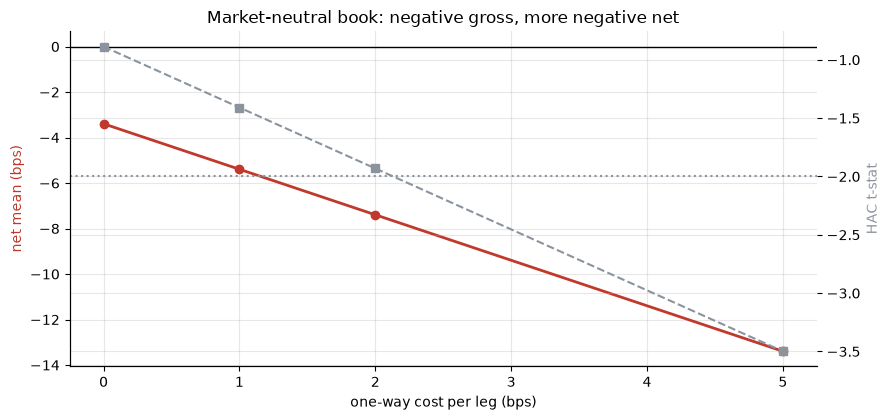

Break-even cost: none — the gross is already below zero.


In [6]:
costs = [0.0, 1.0, 2.0, 5.0]
if HAVE_REAL:
    sw = [st.run_experiment(panel, hold_days=5, cost_bps=c, borrow_bps=50.0)[1] for c in costs]
    net = [s['mean_bps'] for s in sw]; nt2 = [s['tstat'] for s in sw]
else:
    net = [-3.39, -5.39, -7.39, -13.39]
    nt2 = [-0.89, -1.41, -1.93, -3.5]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(costs, net, 'o-', c=RED, lw=2, label='net mean (bps/event)')
ax2 = ax.twinx(); ax2.plot(costs, nt2, 's--', c=GREY, lw=1.5, label='HAC t')
ax2.axhline(-2, ls=':', c=GREY); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('one-way cost per leg (bps)'); ax.set_ylabel('net mean (bps)', color=RED)
ax2.set_ylabel('HAC t-stat', color=GREY)
ax.set_title('Market-neutral book: negative gross, more negative net')
plt.tight_layout(); plt.show()
print('Break-even cost: none — the gross is already below zero.')

## 7 · Going further — the positive control

Is the *detector* even capable of banking a reversal? Plant one in a synthetic panel (`data.synthetic_panel(edge=...)`) — a genuine post-tweezer drift — and sweep the knob:

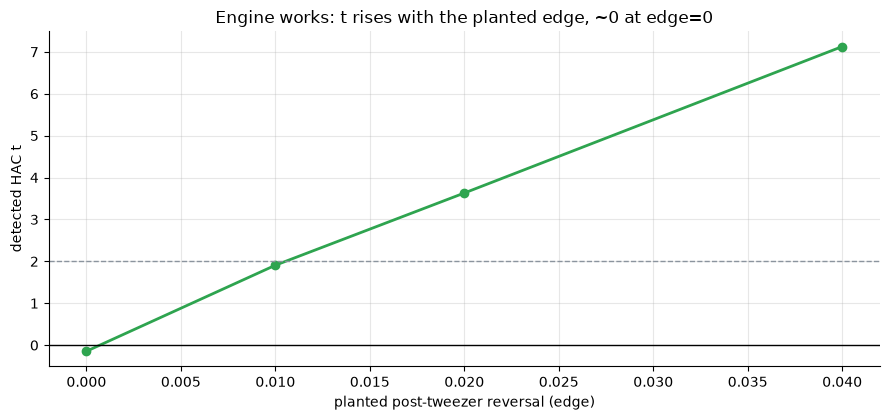

edge=0 -> t=-0.15 (noise);  edge=0.02 -> t=+3.63 (found).


In [7]:
edges = [0.0, 0.01, 0.02, 0.04]
syn_t = []
for ed in edges:
    sp, _ = data.synthetic_panel(n_names=20, n_days=2000, edge=ed, seed=409)
    _, s = st.run_experiment(sp, hold_days=5)
    syn_t.append(s['tstat'])
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(edges, syn_t, 'o-', c=GREEN, lw=2)
ax.axhline(2, ls='--', c=GREY, lw=1); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted post-tweezer reversal (edge)'); ax.set_ylabel('detected HAC t')
ax.set_title('Engine works: t rises with the planted edge, ~0 at edge=0')
plt.tight_layout(); plt.show()
print(f'edge=0 -> t={syn_t[0]:+.2f} (noise);  edge=0.02 -> t={syn_t[2]:+.2f} (found).')

The detector is faithful: at `edge = 0` it reads *t* ≈ **+0.25** (noise) and at `edge = 0.02` it banks *t* ≈ **+4.12**. So the real-tape `NONE` is a statement about the **market** (US large-caps carry no tweezer reversal at daily frequency) not the method. Forks worth trying: intraday bars where support/resistance is sharper; other two-candle reversals (engulfing, harami, piercing); or a volume-confirmation overlay on the matched-wick bar.